# Import Necessary Directories

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings                    
warnings.filterwarnings('ignore')

# Load the dataset

In [4]:
file_name=("C:/Users/Admin/Downloads/1553768847-housing.csv")
data=pd.read_csv(file_name)

# Analyze the dataset

In [6]:
data.shape

(20640, 10)

In [7]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200


In [8]:
data.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,INLAND,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,INLAND,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,INLAND,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,INLAND,84700
20639,-121.24,39.37,16,2785,616.0,1387,530,2.3886,INLAND,89400


In [9]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,INLAND,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,INLAND,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,INLAND,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,INLAND,84700


In [10]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [11]:
print(data.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity', 'median_house_value'],
      dtype='object')


In [12]:
data.nunique()

longitude               844
latitude                862
housing_median_age       52
total_rooms            5926
total_bedrooms         1923
population             3888
households             1815
median_income         12928
ocean_proximity           5
median_house_value     3842
dtype: int64

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  object 
 9   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


In [14]:
for column in data.select_dtypes(include=['object', 'category']).columns:
    print(f"Value counts for column: {column}")
    print(data[column].value_counts())

Value counts for column: ocean_proximity
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


# Check for duplicates

In [16]:
data.duplicated().sum()

0

# Null values

In [18]:
data.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
ocean_proximity         0
median_house_value      0
dtype: int64

# Drop Null Values

In [20]:
#data['total_bedrooms'].fillna(data['total_bedrooms'].mean(), inplace=True)
data.dropna(inplace = True)

In [21]:
data.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
median_house_value    0
dtype: int64

# Check for Outliers

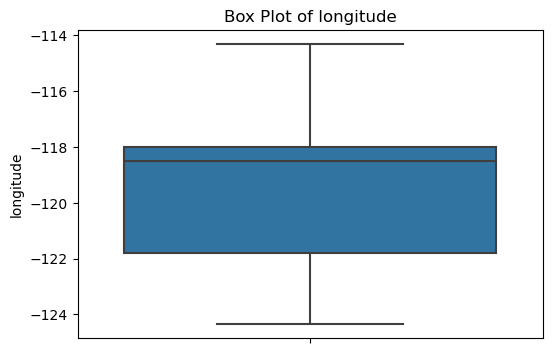

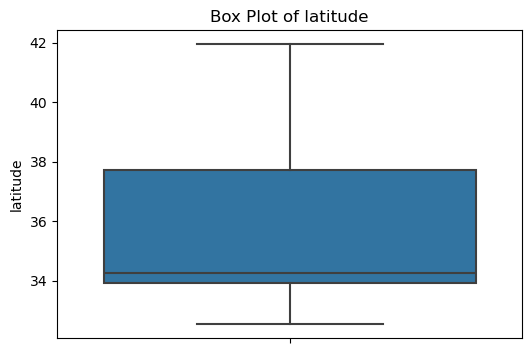

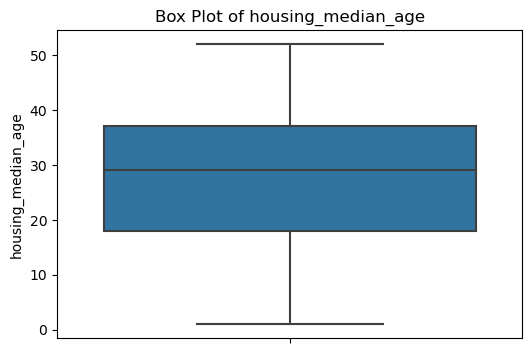

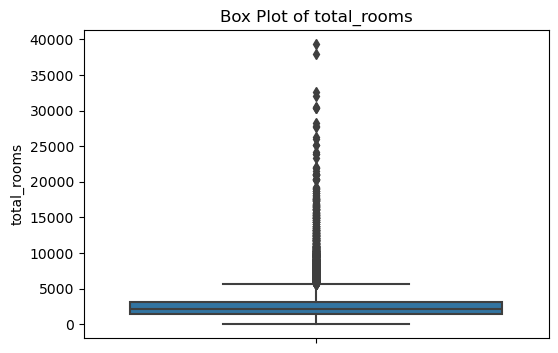

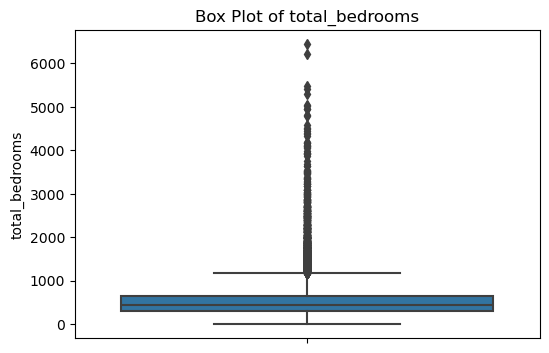

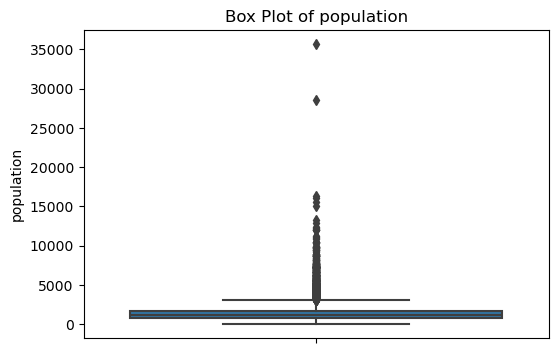

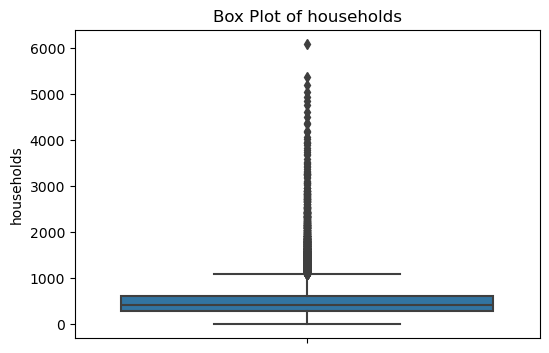

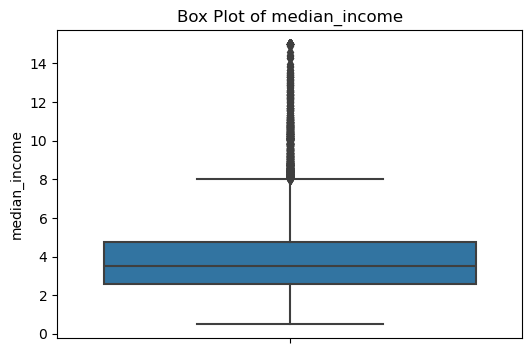

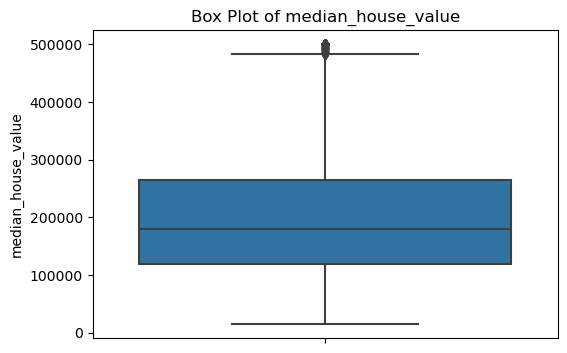

In [23]:
numeric_columns = data.select_dtypes(include=[np.number]).columns
exclude_column='ocean_proximity '
for column in numeric_columns:
    if column != exclude_column:
        plt.figure(figsize=(6, 4))
        sns.boxplot(y=data[column])
        plt.title(f'Box Plot of {column}')
        plt.show()

# vizualization

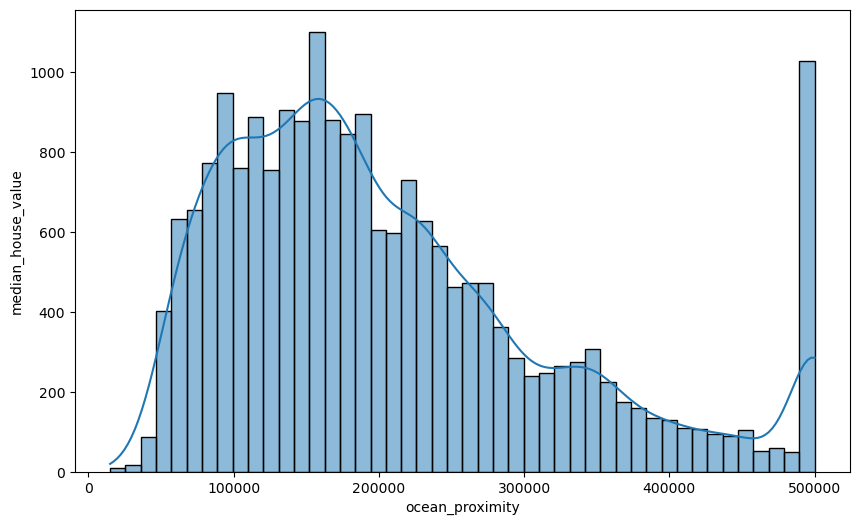

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(data['median_house_value'], kde=True)
plt.xlabel('ocean_proximity')
plt.ylabel('median_house_value')
plt.show()

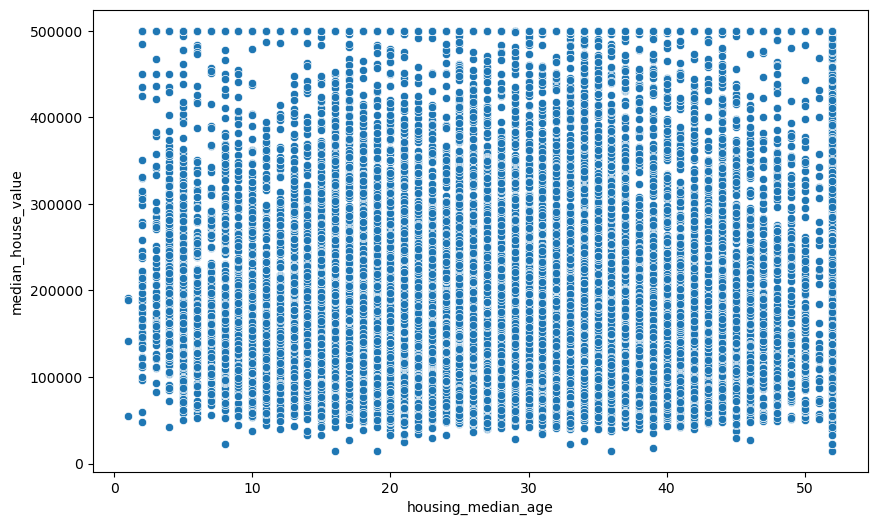

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='housing_median_age', y='median_house_value', data=data)
plt.xlabel('housing_median_age')
plt.ylabel('median_house_value')
plt.show()

# Split the data

In [28]:
X = data.drop('median_house_value', axis=1)
y= data.median_house_value.to_frame()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

(16346, 9) (16346, 1)
(4087, 9) (4087, 1)


# Apply Encoding for x_train and x_test

In [30]:
label_encoder = preprocessing.LabelEncoder()
for i in X_train.select_dtypes (include="object").columns:
     #if i not in exclude_columns:
     X_train[i]= label_encoder.fit_transform(X_train[i])

In [31]:
label_encoder = preprocessing.LabelEncoder()
for i in X_test.select_dtypes (include="object").columns:
     #if i not in exclude_columns:
     X_test[i]= label_encoder.fit_transform(X_test[i])

# Apply scaling for x_train and x_test

In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelling

In [35]:
# Initialize the Linear Regression model
model = LinearRegression()
# Train the model
model.fit(X_train_scaled, y_train)
# Predict on the test set
y_pred = model.predict(X_test_scaled)
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

Mean Squared Error: 4924108937.91
R^2 Score: 0.64


In [36]:
# Initialize the Decision Tree Regressor model
decision_tree_model = DecisionTreeRegressor(random_state=42)
# Train the model
decision_tree_model.fit(X_train_scaled, y_train)
# Predict on the test set
y_pred = decision_tree_model.predict(X_test_scaled)
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

Mean Squared Error: 4700945271.68
R^2 Score: 0.66


In [37]:
# Initialize the Random Forest Regressor model
random_forest_model = RandomForestRegressor(random_state=42)
# Train the model
random_forest_model.fit(X_train_scaled, y_train)
# Predict on the test set
y_pred = random_forest_model.predict(X_test_scaled)
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

Mean Squared Error: 2449867692.92
R^2 Score: 0.82


In [38]:
svr_model = SVR()  # You can adjust C and epsilon
svr_model.fit(X_train_scaled, y_train)
# Make predictions on the test set
y_pred = svr_model.predict(X_test_scaled)
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R² Score: {r2}')

Mean Squared Error: 14358487263.352772
R² Score: -0.04996690632427914


In [39]:
k = 5  # You can choose the number of neighbors
knn_regressor = KNeighborsRegressor(n_neighbors=k)
# Fit the model
knn_regressor.fit(X_train_scaled, y_train)
# Make predictions
y_pred = knn_regressor.predict(X_test_scaled)
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')
print(f'R2: {r2:.2f}')

Mean Squared Error: 3887008845.85
R2: 0.72


# Random Forest has best R2 score